In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import seaborn as sns

# Import your implementations
from students import data_processing, regression, classification, evaluation

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load data
df = data_processing.load_heart_disease_data('/Users/alexandrianelson/Desktop/BINF5507 - Github Classroom/assignment-2-supervised-learning-alexandrianelson/data/heart_disease_uci.csv')
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum().sum()} total missing")

# Preprocess
df_clean = data_processing.preprocess_data(df)
print(f"\nPreprocessed data shape: {df_clean.shape}")
print(f"Data types: {df_clean.dtypes.unique()}")

Loaded data shape: (920, 15)
Columns: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Missing values:
1759 total missing
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                     0
ca                          0
num                         0
sex_Female                  0
sex_Male                    0
dataset_Cleveland           0
dataset_Hungary             0
dataset_Switzerland         0
dataset_VA Long Beach       0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
fbs_False                   0
fbs_

Regression data shapes: X=(918, 29), y=(918,)
<class 'pandas.core.series.Series'>
0    233.0
1    286.0
2    229.0
3    250.0
4    204.0
Name: chol, dtype: float64
Unique values: 217
1
Train shape: (734, 29), Test shape: (184, 29)

Training ElasticNet grid search...
Grid search results shape: (9, 4)
R² range: 0.533 to 0.616


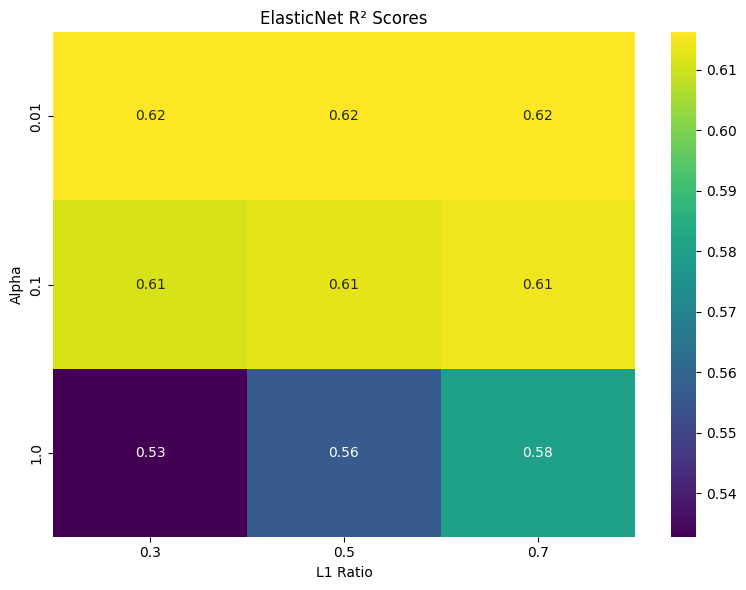


Best ElasticNet:
  l1_ratio: 0.3
  alpha: 0.1
  Test R²: 0.573


In [3]:
# Prepare regression data
X_reg, y_reg = data_processing.prepare_regression_data(df_clean, target='chol')
print(f"Regression data shapes: X={X_reg.shape}, y={y_reg.shape}")

print(type(y_reg))
print(y_reg.head())
print("Unique values:", y_reg.nunique())
print(y_reg.value_counts().min())

# Split and scale
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = data_processing.split_and_scale(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train_reg.shape}, Test shape: {X_test_reg.shape}")

# Train ElasticNet with grid search
print("\nTraining ElasticNet grid search...")
results = regression.train_elasticnet_grid(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)
print(f"Grid search results shape: {results.shape}")
print(f"R² range: {results['r2_score'].min():.3f} to {results['r2_score'].max():.3f}")

# Create heatmap
fig = regression.create_r2_heatmap(
    results,
    [0.3, 0.5, 0.7],
    [0.01, 0.1, 1.0]
)
plt.title('ElasticNet R² Scores')
plt.tight_layout()
plt.show()

# Get best model
reg_best = regression.get_best_elasticnet_model(
    X_train_reg, y_train_reg, X_test_reg, y_test_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)
print(f"\nBest ElasticNet:")
print(f"  l1_ratio: {reg_best['best_l1_ratio']}")
print(f"  alpha: {reg_best['best_alpha']}")
print(f"  Test R²: {reg_best['test_r2']:.3f}")

In [4]:
# Prepare classification data
X_clf, y_clf = data_processing.prepare_classification_data(df_clean, target='num')
print(f"Classification data shapes: X={X_clf.shape}, y={y_clf.shape}")
print(f"Class distribution: {np.bincount(y_clf.astype(int))}")

# Split and scale
X_train_clf, X_test_clf, y_train_clf, y_test_clf, scaler_clf = data_processing.split_and_scale(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"\nTrain shape: {X_train_clf.shape}, Test shape: {X_test_clf.shape}")

Classification data shapes: X=(918, 28), y=(918,)
Class distribution: [410 508]

Train shape: (734, 28), Test shape: (184, 28)


Training Logistic Regression grid search...
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

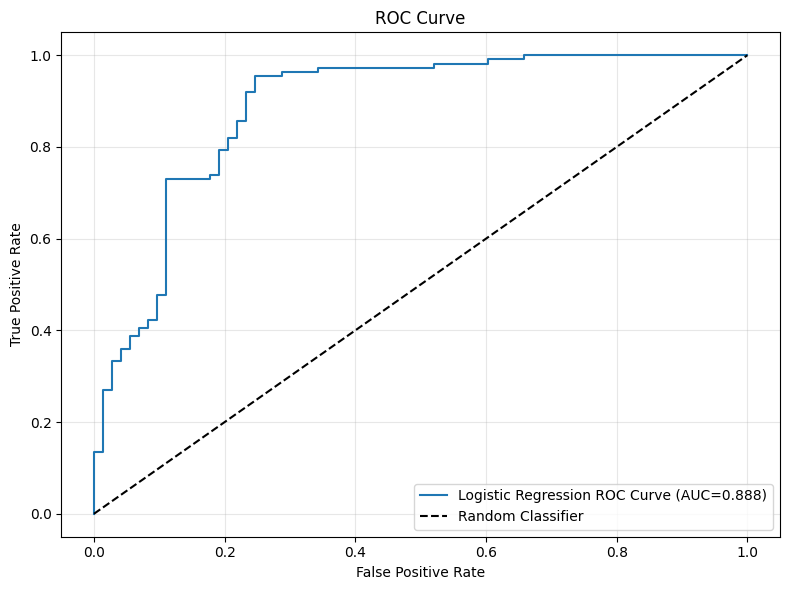

In [5]:
# Train logistic regression
print("Training Logistic Regression grid search...")
gs_lr = classification.train_logistic_regression_grid(X_train_clf, y_train_clf)
print(f"Best parameters: {gs_lr.best_params_}")

# Get best model
lr_best = classification.get_best_logistic_regression(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)

# Get probability predictions for curves
y_pred_lr = lr_best['model'].predict_proba(X_test_clf)[:, 1]

# Plot AUROC curve
fig_lr = evaluation.generate_auroc_curve(y_test_clf, y_pred_lr, model_name='Logistic Regression')
plt.tight_layout()
plt.show()

Training k-NN grid search...
Best parameters: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}


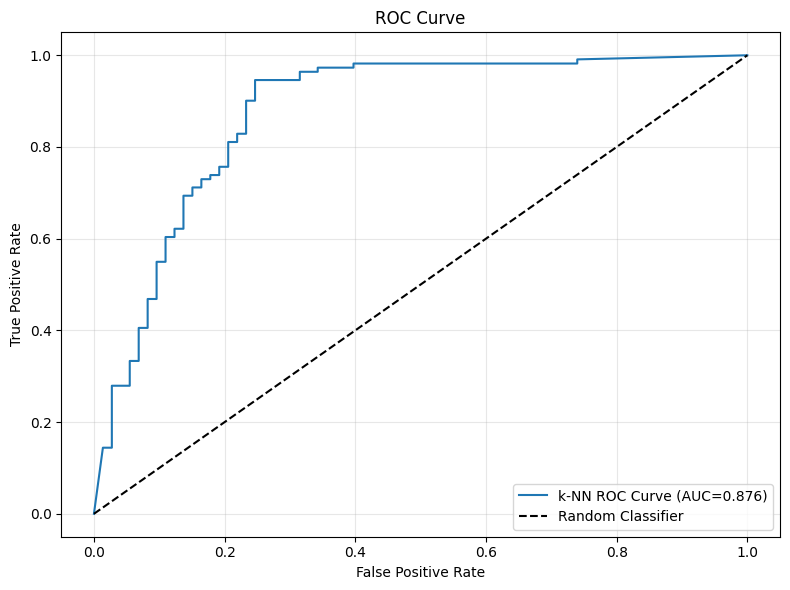

In [6]:
# Train k-NN
print("Training k-NN grid search...")
gs_knn = classification.train_knn_grid(X_train_clf, y_train_clf)
print(f"Best parameters: {gs_knn.best_params_}")

# Get best model
knn_best = classification.get_best_knn(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)

# Get probability predictions
y_pred_knn = knn_best['model'].predict_proba(X_test_clf)[:, 1]

# Plot AUROC curve
fig_knn = evaluation.generate_auroc_curve(y_test_clf, y_pred_knn, model_name='k-NN')
plt.tight_layout()
plt.show()

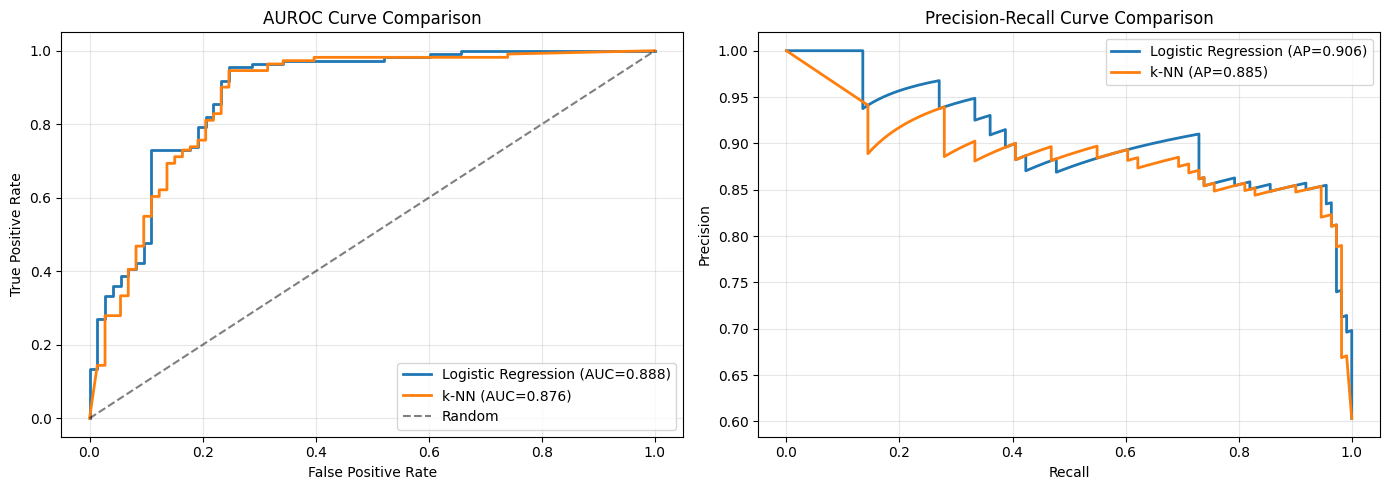


MODEL COMPARISON SUMMARY
Logistic Regression:
  AUROC: 0.888
  AUPRC: 0.906

k-NN:
  AUROC: 0.876
  AUPRC: 0.885

Better model: Logistic Regression


In [7]:
# Compare AUROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUROC comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test_clf, y_pred_lr)
auc_lr = roc_auc_score(y_test_clf, y_pred_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, y_pred_knn)
auc_knn = roc_auc_score(y_test_clf, y_pred_knn)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
axes[0].plot(fpr_knn, tpr_knn, label=f'k-NN (AUC={auc_knn:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('AUROC Curve Comparison')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR comparison
precision_lr, recall_lr, _ = precision_recall_curve(y_test_clf, y_pred_lr)
ap_lr = average_precision_score(y_test_clf, y_pred_lr)
precision_knn, recall_knn, _ = precision_recall_curve(y_test_clf, y_pred_knn)
ap_knn = average_precision_score(y_test_clf, y_pred_knn)

axes[1].plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={ap_lr:.3f})', linewidth=2)
axes[1].plot(recall_knn, precision_knn, label=f'k-NN (AP={ap_knn:.3f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Logistic Regression:")
print(f"  AUROC: {auc_lr:.3f}")
print(f"  AUPRC: {ap_lr:.3f}")
print(f"\nk-NN:")
print(f"  AUROC: {auc_knn:.3f}")
print(f"  AUPRC: {ap_knn:.3f}")
print(f"\nBetter model: {'Logistic Regression' if auc_lr > auc_knn else 'k-NN'}")
print("="*60)